In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import statsmodels.api as sm



from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [2]:
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'


In [3]:
#conversion factors
cm_to_mm = 10
scale = 0.1

In [4]:
pexq_df = pd.read_csv(save_dir + 'pexq_df.csv')


### ED Fig. 5: basin level all obs

In [5]:
# load panel and regression results at basin level, to set up basin data
basin_models = pd.read_csv(save_dir+'basin_models_no_interaction_GPCC.csv')
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')

#load basin id
basin_id_df = pd.read_csv(save_dir+'basin_id_df.csv')

#merge onto full df
pexq_df['basin_id'] = basin_id_df['basin_id']

In [6]:
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')

In [7]:
names = []
for i in basin_models['basin_id']:
    names.append(grdc_basins[grdc_basins.MRBID == i].RIVER_BASI.values[0])

basin_models['basin_name'] = names

In [8]:
#bring in mean precip from pexq_df dataset:
Pmeanlist = []
for i in basin_models.index:
    Pmeanlist.append(pexq_df[pexq_df.basin_id == int(basin_models.loc[i].basin_id)].Pmean.mean())

basin_models['Pmean'] = Pmeanlist

# for interaction model, compute full Gp coef and add to df:
#basin_models['dTWS/dGp'] = basin_models['coef_Gp']+basin_models['coef_Gp_Pmean']*basin_models['Pmean']*scale*cm_to_mm

grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})
merged = grdc_basins.merge(basin_models, on='basin_id', how='left')

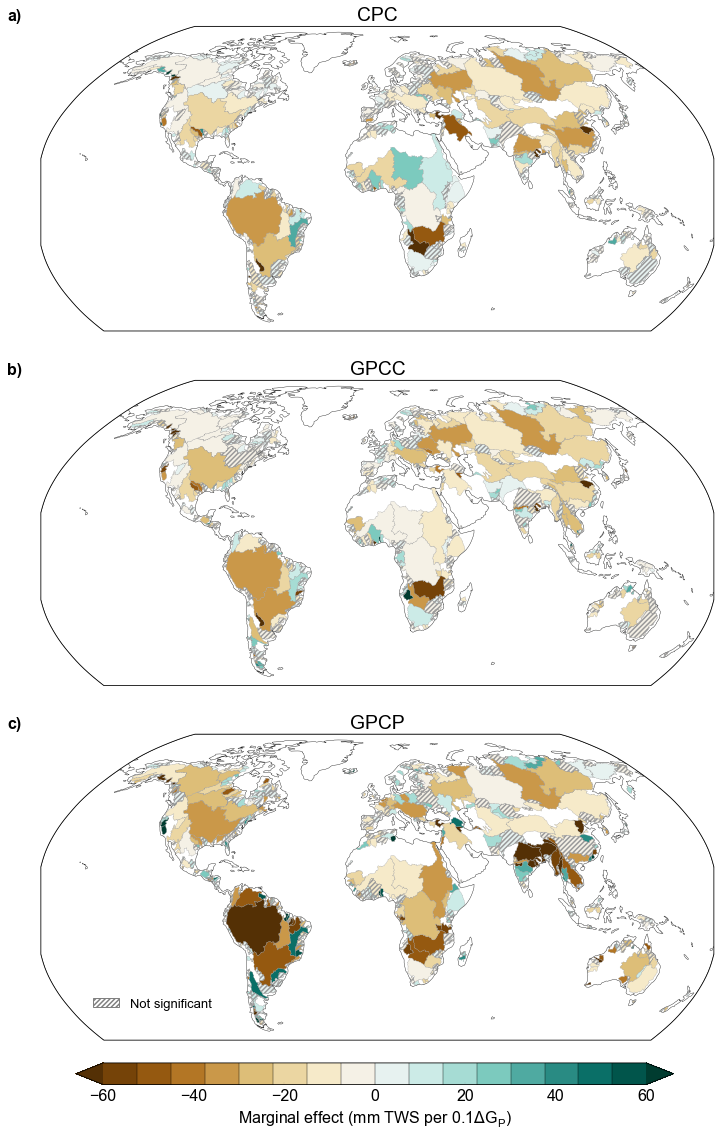

In [9]:
# now plot the basin coefficients on the basin shapefiles, for each P dataset:
dset = ['CPC','GPCC','GPCP']
dset_suffix = ['','_GPCC','_GPCP']


fig = plt.figure(figsize=(10,15))

axs = []
gs = GridSpec(3, 1)

axs.append(fig.add_subplot(gs[0,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[1,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[2,0],projection=ccrs.Robinson()))

for i,ax in enumerate(axs):
    basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[i]+'.csv')
    grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')

    grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})
    merged = grdc_basins.merge(basin_models, on='basin_id', how='left')

    #select column to plot
    plotdat = 'coef_Gp'
    sigdat = 'pval_Gp'

    # set colors
    vmin = -60
    vmax = 60
    ncol = 17 # choose a number greater than
             # the number of colors you actually want
    bounds = np.linspace(vmin,vmax,ncol)
    cmapname = 'BrBG'
    cols = plt.get_cmap(cmapname)(np.linspace(0,1,len(bounds)+1))
    cmap = colors.ListedColormap(cols[1:-1])
    cmap.set_over(cols[-1])
    cmap.set_under(cols[0])
    norm = colors.Normalize(vmin=vmin,vmax=vmax)
    cbar = plt.cm.ScalarMappable(norm=norm,cmap=cmap)

    # map
    merged.plot(column=plotdat,transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, linewidth=0.2, ax=ax, edgecolor='0.6', legend=False)

    ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='0.1',facecolor=[1,1,1],linewidth=0.4) 

    hatch_polygons = merged[merged[sigdat] > 0.05]
    hatch_polygons.plot(transform=ccrs.PlateCarree(),
        ax=ax, 
        facecolor="none",  # No fill color for hatching layer
        edgecolor='0.6',   # Keep border color consistent
        hatch='/////',      # Choose your hatch pattern
        linewidth=0.2
    )

    ax.set_title(dset[i])
    
cbar_ax = fig.add_axes([0.09,-0.02,0.83,0.02])
plt.setp(cbar_ax.spines.values(), linewidth=0.3)
#tks = [-2,-1,0,1,2]
cb = fig.colorbar(cbar,cax=cbar_ax,orientation="horizontal",
                          drawedges=True,extend="both")#,ticks=tks)
cbar_ax.tick_params(direction="in",width=0.05)
cb.set_label(label=r"Marginal effect (mm TWS per 0.1$\Delta G_P$)")

# lettering
lets = 'abcdefghi'

for i,ax in enumerate(axs):
    ax.text(-0.05,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')

b = ax.bar(-1,-1,facecolor='none',edgecolor='grey',hatch='/////')
ax.legend([b],['Not significant'],fontsize=13,loc=(0.07,0.08),frameon=False)

fig.canvas.draw()
plt.tight_layout()


plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/accepted/EDFig5.png',bbox_inches='tight',dpi=200)